<a href="https://colab.research.google.com/github/BiswarupMukherjee1/spacecraft-pose-failure-detection/blob/main/exp4_cnn_vs_vit_pose_regression_speedplus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN and vision transformer pose regression on SPEED+

Biswarup Mukherjee

Exp 1, 2 and 3 ran on a wireframe target that was rendered, with exact ground
truth. That was useful for isolating a question, and it was also its main weakness:
nothing in it measured the distance between rendered images and real ones, which the
literature identifies as the central open problem.

This experiment uses SPEED+ (Park, Maertens, Lecuyer, Izzo and D'Amico, IEEE
Aerospace 2022). It contains 59,960
labelled synthetic images of the Tango spacecraft from the PRISMA mission, and two
hardware-in-the-loop domains photographed in Stanford SLAB's TRON facility:
*lightbox*, which simulates Earth albedo through diffuser plates, and *sunlamp*,
which simulates direct sunlight with a metal-halide lamp. It was the benchmark for the second Satellite Pose Estimation Competition, SPEC2021.

During SPEC2021 pose estimation competition, the two hardware-in-the-loop domains were released without labels, since a programme has no labelled imagery of its target in the operational environment before flight. The v2 archive used here includes those labels, released after the competition closed, so the domain gap can be measured directly rather than inferred from prediction statistics.

Two backbones are compared under an identical head, loss and training schedule:

| Backbone | Type | Parameters trained |
|---|---|---|
| ResNet-18 | convolutional, ImageNet-pretrained | all |
| DINOv2 ViT-S/14 | self-supervised vision transformer | head only, backbone frozen |

The comparison is restricted to the backbone. Anything else that
differed would make the result uninterpretable.


# SPEED+ dataset
SPEED+ is published on Zenodo as a single 16.9 GB archive, speedplusv2.zip (record 5588480, DOI 10.25740/wv398fc4383, CC-BY-4.0). The archive is downloaded once to Drive and verified by size before use.

Extraction is selective. The label files are a few megabytes and are taken whole, while only the first N images of each split are extracted to the session disk, which is fast local storage. Reading tens of thousands of small files through a mounted Drive is slow enough to dominate the run, so the working copy is kept local and re-extracted per session.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
CODE = "/content/drive/MyDrive/SENER_PROJ2/code"
if CODE not in sys.path:
    sys.path.insert(0, CODE)

import os
print("modules found:", sorted(f for f in os.listdir(CODE) if f.endswith(".py")))

modules found: ['exp6_ekf_mc.py', 'exp7_efficiency.py', 'pose_models.py', 'sc_common.py', 'speedplus_data.py', 'speedplus_fetch.py']


In [ ]:
!pip install -q opencv-contrib-python transformers 2>&1 | tail -2

In [ ]:
import os, time, numpy as np, torch, cv2, matplotlib.pyplot as plt
import speedplus_data as SP
import pose_models as PM
import speedplus_fetch as SF

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


ZIP            = "/content/drive/MyDrive/SENER_PROJ2/data/speedplusv2.zip"
SPEEDPLUS_ROOT = "/content/speedplus"
IMG_SIZE       = 224
N_TRAIN, N_VAL, N_HIL = 8000, 1500, 600

if not os.path.exists(os.path.join(SPEEDPLUS_ROOT, "camera.json")):
    assert SF.verify_zip(ZIP), "archive missing or incomplete"
    SF.extract_subset(ZIP, SPEEDPLUS_ROOT,
                      n_synth_train=N_TRAIN, n_synth_val=N_VAL, n_hil=N_HIL)
SF.summarise(SPEEDPLUS_ROOT)

K, dist, (W, H) = SP.load_camera(SPEEDPLUS_ROOT)
print("camera focal lengths:", np.diag(K)[:2].round(1), " native image size:", (W, H))

train_recs = SP.load_split(SPEEDPLUS_ROOT, "synthetic", "train")
val_recs   = SP.load_split(SPEEDPLUS_ROOT, "synthetic", "validation")
print(f"synthetic: {len(train_recs)} train, {len(val_recs)} validation (labelled)")

hil = {}
for dom in ["lightbox", "sunlamp"]:
    try:
        r = SP.load_split(SPEEDPLUS_ROOT, dom, "test")
        hil[dom] = r
        print(f"{dom}: {len(r)} images, labelled = {r[0]['t'] is not None}")
    except Exception as e:
        print(f"{dom}: not present ({type(e).__name__})")

device: cuda
archive size: 16.93 GB (expected about 16.9)
archive opens correctly, 69504 entries
archive root: 'speedplusv2/'
  wrote camera.json
  wrote synthetic/train.json
  wrote synthetic/validation.json
  wrote lightbox/test.json
  wrote sunlamp/test.json
    synthetic/train.json: 1000 extracted so far
    synthetic/train.json: 2000 extracted so far
    synthetic/train.json: 3000 extracted so far
    synthetic/train.json: 4000 extracted so far
    synthetic/train.json: 5000 extracted so far
    synthetic/train.json: 6000 extracted so far
    synthetic/train.json: 7000 extracted so far
    synthetic/train.json: 8000 extracted so far
  synthetic/train.json: 8000 new  (target 8000)
    synthetic/validation.json: 1000 extracted so far
  synthetic/validation.json: 1500 new  (target 1500)
  lightbox/test.json: 600 new  (target 600)
  sunlamp/test.json: 600 new  (target 600)
camera.json     : found
synthetic/train      :  47966 records in json,   9500 images on disk
synthetic/validation

## 1. Loading the data


    8000 of 47966 images present on disk
    loaded 2000/8000
    loaded 4000/8000
    loaded 6000/8000
    loaded 8000/8000
    1500 of 11994 images present on disk
    600 of 6740 images present on disk
    600 of 2791 images present on disk
loaded in 144 s: train (8000, 1, 224, 224), val (1500, 1, 224, 224), lightbox 600, sunlamp 600
range in the training set: 2.3 to 10.0 m


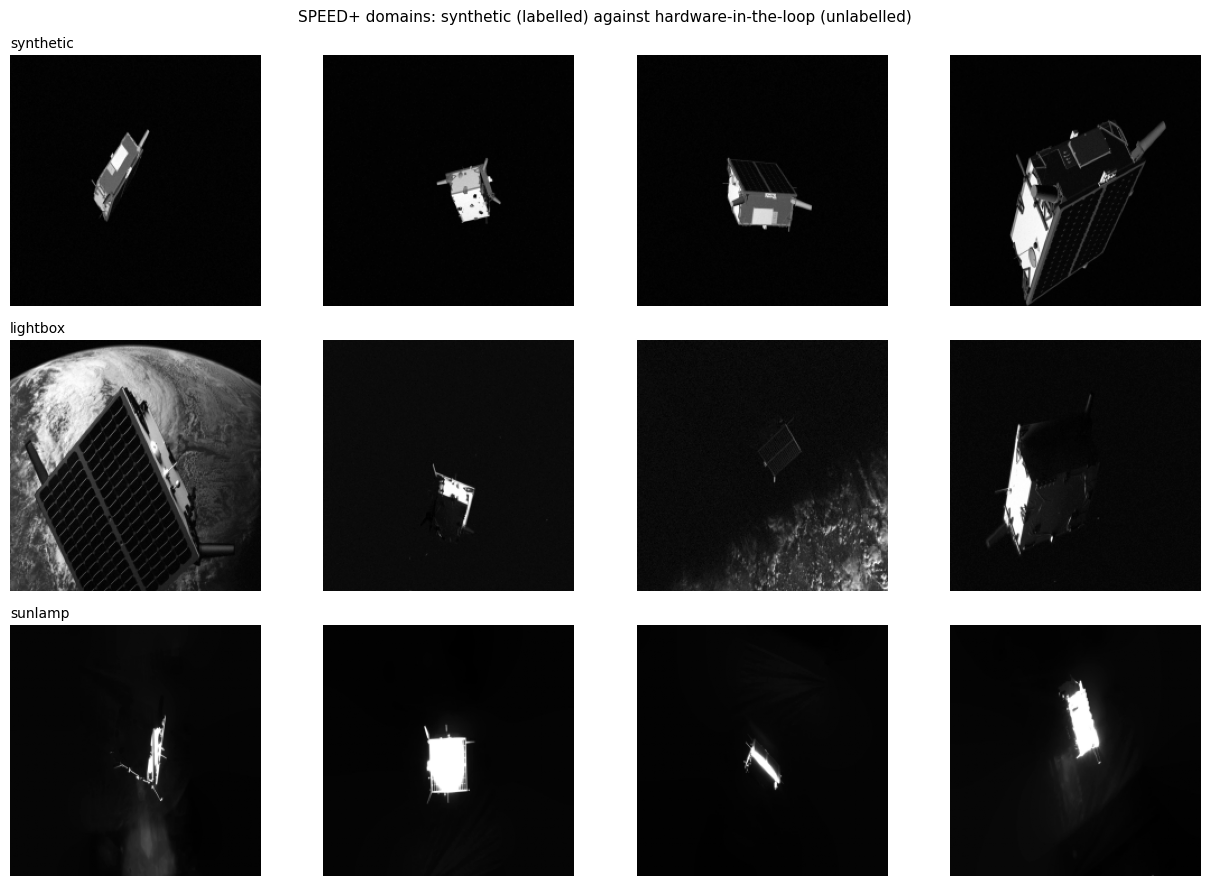

In [ ]:
t0 = time.time()
Xtr, Ttr, Qtr = SP.build_arrays(train_recs, size=IMG_SIZE, limit=N_TRAIN, labelled=True)
Xva, Tva, Qva = SP.build_arrays(val_recs,   size=IMG_SIZE, limit=N_VAL,  labelled=True)
Xhil = {d: SP.build_arrays(r, size=IMG_SIZE, limit=N_HIL, labelled=False)[0]
        for d, r in hil.items()}
print(f"loaded in {time.time()-t0:.0f} s: train {Xtr.shape}, val {Xva.shape}, "
      + ", ".join(f"{d} {v.shape[0]}" for d, v in Xhil.items()))
print(f"range in the training set: {np.linalg.norm(Ttr,axis=1).min():.1f} to "
      f"{np.linalg.norm(Ttr,axis=1).max():.1f} m")

n_show = 4
doms = [("synthetic", Xva)] + list(Xhil.items())
fig, axes = plt.subplots(len(doms), n_show, figsize=(3.2*n_show, 3.0*len(doms)), squeeze=False)
for r, (name, Xd) in enumerate(doms):
    for c in range(n_show):
        axes[r][c].imshow(Xd[min(c, len(Xd)-1), 0], cmap="gray")
        axes[r][c].axis("off")
    axes[r][0].set_ylabel(name)
    axes[r][0].set_title(name, loc="left", fontsize=10)
plt.suptitle("SPEED+ domains: synthetic (labelled) against hardware-in-the-loop domains",
             fontsize=11)
plt.tight_layout(); plt.show()

## 2. Labels

SPEED+ gives, per image, a scalar-first quaternion for relative attitude and a
translation in metres. The following checks can be done before training on them: the quaternion has to
convert to a proper rotation matrix, and the angular metric must treat q and -q as
the same rotation.

R R^T = I : True | det(R) = 1.0
angle(q, q)  = 0.0002 deg
angle(q, -q) = 0.0002 deg  (must also be 0)


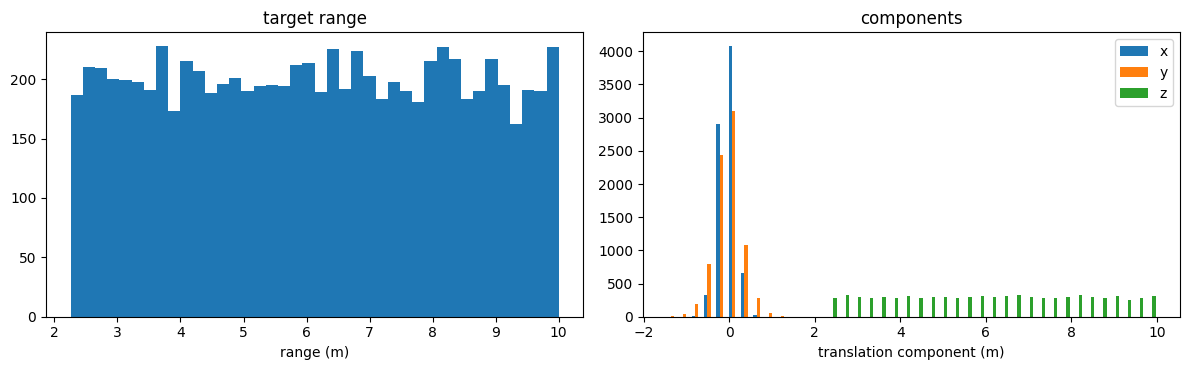

In [ ]:
R = SP.quat_to_R(Qtr[0])
print("R R^T = I :", np.allclose(R @ R.T, np.eye(3), atol=1e-5),
      "| det(R) =", round(float(np.linalg.det(R)), 6))
print("angle(q, q)  =", round(SP.quat_angle_deg(Qtr[0], Qtr[0]), 4), "deg")
print("angle(q, -q) =", round(SP.quat_angle_deg(Qtr[0], -Qtr[0]), 4), "deg  (must also be 0)")

rng_tr = np.linalg.norm(Ttr, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(rng_tr, bins=40); axes[0].set_xlabel("range (m)"); axes[0].set_title("target range")
axes[1].hist([Ttr[:,0], Ttr[:,1], Ttr[:,2]], bins=40, label=["x","y","z"])
axes[1].legend(); axes[1].set_xlabel("translation component (m)"); axes[1].set_title("components")
plt.tight_layout(); plt.show()

## 3. The two models

The head is shared. It predicts translation, a per-axis log-variance for that
translation, and a quaternion. The variance output is not used in this notebook and
is the subject of Experiment 5; it is present here so that both notebooks train the
same network and the comparison carries over.

The loss on translation is a heteroscedastic Gaussian negative log-likelihood, and
the loss on attitude is 1 minus the absolute dot product between the predicted and
true quaternions. Absolute value is used here, It is what handles the double cover; without it
the network is punished for a correct answer written with the opposite sign.

In [ ]:
models = {}
m_cnn, tag_cnn = PM.build_model("cnn", p_drop=0.2, t_scale=float(np.abs(Ttr).mean()*2))
models["CNN"] = (m_cnn, tag_cnn)
print(f"CNN  : {tag_cnn}, {sum(p.numel() for p in m_cnn.parameters()):,} parameters "
      f"({sum(p.numel() for p in m_cnn.parameters() if p.requires_grad):,} trainable)")

try:
    m_vit, tag_vit = PM.build_model("vit", p_drop=0.2, freeze_vit=True,
                                    t_scale=float(np.abs(Ttr).mean()*2))
    models["ViT"] = (m_vit, tag_vit)
    print(f"ViT  : {tag_vit}, {sum(p.numel() for p in m_vit.parameters()):,} parameters "
          f"({sum(p.numel() for p in m_vit.parameters() if p.requires_grad):,} trainable)")
except Exception as e:
    print("ViT unavailable:", type(e).__name__, str(e)[:200])

print("\ntraining:", list(models))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


CNN  : resnet18, 11,566,794 parameters (11,566,794 trainable)


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

ViT  : dinov2-small-frozen, 22,584,202 parameters (527,626 trainable)

training: ['CNN', 'ViT']


## 4. Training

Same schedule for both. The ViT backbone is frozen, so only the 0.53 M parameters of its head are updated, against all 11.6 M of the ResNet-18. Per-epoch time is reported because freezing removes the backward pass through the backbone but not the forward pass, and the measured cost is reported below.

In [ ]:
EPOCHS, BATCH, LR = 12, 32, 1e-3

history = {}
for name, (m, tag) in models.items():
    print(f"--- {name} ({tag}) ---")
    t0 = time.time()
    PM.train(m, Xtr, Ttr, Qtr, epochs=EPOCHS, bs=BATCH, lr=LR, device=device,
             val=(Xva[:400], Tva[:400], Qva[:400]))
    history[name] = time.time() - t0
    print(f"    {history[name]:.0f} s total, {history[name]/EPOCHS:.0f} s/epoch\n")

--- CNN (resnet18) ---
  epoch  1/12  loss +2.4643   val  t 0.749 m   rot 65.13 deg
  epoch  2/12  loss +0.7748   val  t 0.649 m   rot 63.41 deg
  epoch  3/12  loss +0.6227   val  t 1.183 m   rot 74.87 deg
  epoch  4/12  loss +0.6037   val  t 0.531 m   rot 58.52 deg
  epoch  5/12  loss +0.3576   val  t 1.071 m   rot 71.76 deg
  epoch  6/12  loss +0.3506   val  t 0.614 m   rot 70.96 deg
  epoch  7/12  loss +0.2990   val  t 0.424 m   rot 54.01 deg
  epoch  8/12  loss -0.1462   val  t 0.423 m   rot 43.58 deg
  epoch  9/12  loss -0.3792   val  t 0.338 m   rot 34.50 deg
  epoch 10/12  loss -0.6079   val  t 0.295 m   rot 31.80 deg
  epoch 11/12  loss -0.7144   val  t 0.278 m   rot 28.82 deg
  epoch 12/12  loss -0.8427   val  t 0.284 m   rot 27.30 deg
    294 s total, 24 s/epoch

--- ViT (dinov2-small-frozen) ---
  epoch  1/12  loss +2.8039   val  t 0.554 m   rot 101.47 deg
  epoch  2/12  loss +1.6965   val  t 0.474 m   rot 83.56 deg
  epoch  3/12  loss +1.2812   val  t 0.482 m   rot 81.73 de

## 5. Accuracy on the synthetic domain

Both models are trained on 8,000 synthetic images for 12 epochs and evaluated on 1,500 held-out synthetic images. Translation error is reported in metres and as a fraction of range.

CNN  median translation 0.271 m (5.07% of range) | median rotation 27.46 deg | 294 s train
ViT  median translation 0.366 m (6.33% of range) | median rotation 52.94 deg | 509 s train


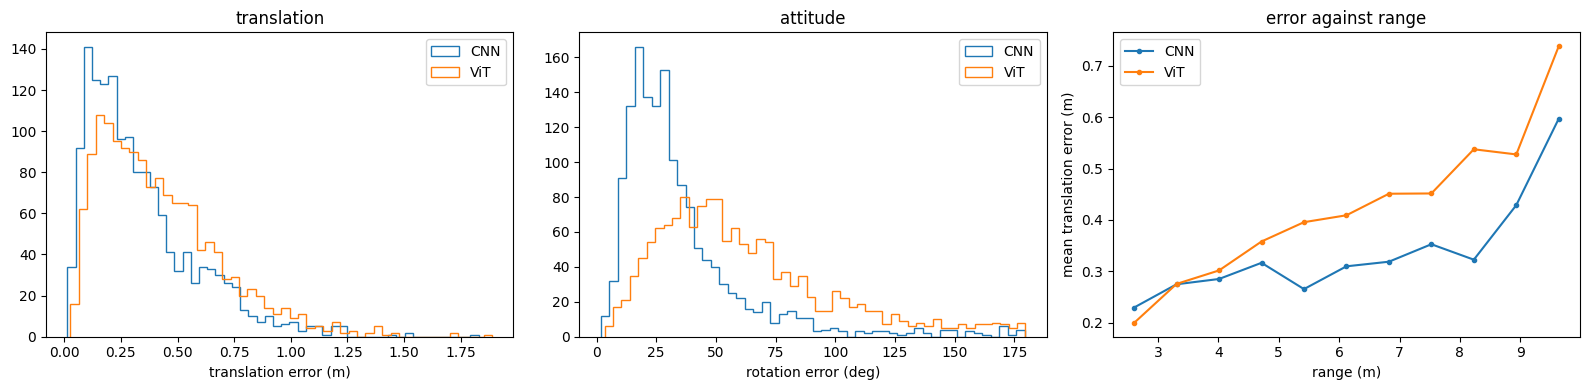

In [ ]:
rows = []
for name, (m, tag) in models.items():
    ev = PM.evaluate(m, Xva, Tva, Qva, device=device)
    rows.append((name, tag, ev))
    print(f"{name:4s} median translation {ev['t_err_median']:.3f} m "
          f"({ev['t_err_rel_median']*100:.2f}% of range) | "
          f"median rotation {ev['q_err_median']:.2f} deg | {history[name]:.0f} s train")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, tag, ev in rows:
    axes[0].hist(ev["t_err"], bins=50, histtype="step", lw=1.6, label=name)
    axes[1].hist(ev["q_err"], bins=50, histtype="step", lw=1.6, label=name)
    b = np.linspace(ev["range"].min(), ev["range"].max(), 12)
    idx = np.digitize(ev["range"], b)
    mu = [ev["t_err"][idx == i].mean() if (idx == i).sum() > 5 else np.nan
          for i in range(1, len(b))]
    axes[2].plot(0.5*(b[1:]+b[:-1]), mu, "-o", ms=3, label=name)
axes[0].set_xlabel("translation error (m)"); axes[0].legend(); axes[0].set_title("translation")
axes[1].set_xlabel("rotation error (deg)"); axes[1].legend(); axes[1].set_title("attitude")
axes[2].set_xlabel("range (m)"); axes[2].set_ylabel("mean translation error (m)")
axes[2].legend(); axes[2].set_title("error against range")
plt.tight_layout(); plt.show()

## 6. Which axis carries the error

A single camera recovers lateral position from where the target sits in the image,
and range only from how large it appears. The two are not equally observable and the
error should not be isotropic. This is the same reason the reference architecture for
cooperative docking takes range from a laser rangefinder rather than from the
camera.

In [ ]:
for name, (m, tag) in models.items():
    t, lv, q = PM.predict(m, Xva, device=device)
    e = t - Tva
    los = Tva / np.linalg.norm(Tva, axis=1, keepdims=True)
    along = np.abs((e * los).sum(1))
    across = np.linalg.norm(e - (e * los).sum(1)[:, None] * los, axis=1)
    print(f"{name:4s} along-boresight (range) {np.median(along):.3f} m | "
          f"across-boresight (lateral) {np.median(across):.3f} m | "
          f"ratio {np.median(along)/max(np.median(across),1e-9):.1f}x")

CNN  along-boresight (range) 0.258 m | across-boresight (lateral) 0.061 m | ratio 4.2x
ViT  along-boresight (range) 0.297 m | across-boresight (lateral) 0.138 m | ratio 2.2x


## 7. Behaviour on the hardware-in-the-loop domains

The sample images show what changes between domains. The synthetic images are evenly lit against a black background. The lightbox images place Earth in the frame, which is both a bright distractor and a source of low contrast against the target. The sunlamp images saturate the illuminated face of the spacecraft and add stray light, leaving little usable structure.

The following two things are measured. The distribution of predicted range, which needs no labels and shows whether a model is still responding to image content; and, since the SPEED+ v2 data release includes labels for these domains, the actual pose error.

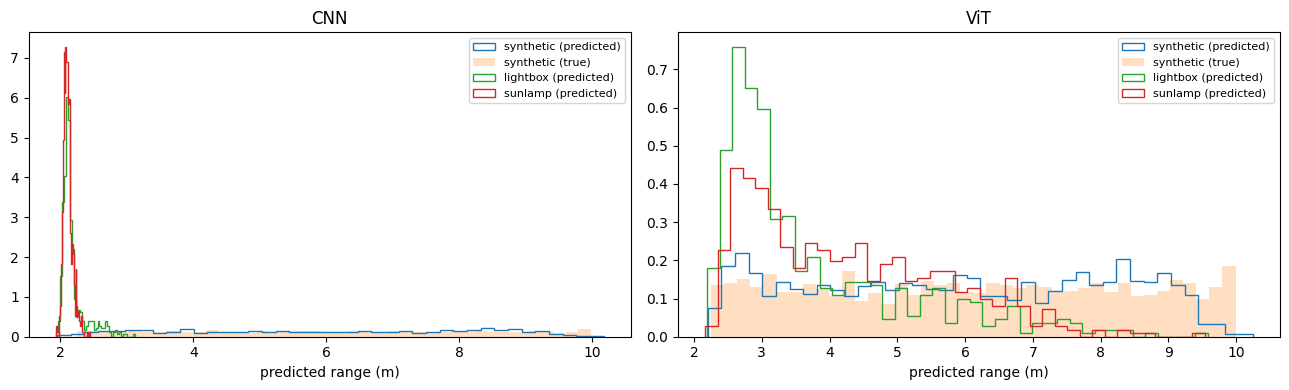

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(6.5*len(models), 4), squeeze=False)
for ax, (name, (m, tag)) in zip(axes[0], models.items()):
    t_syn, _, _ = PM.predict(m, Xva, device=device)
    ax.hist(np.linalg.norm(t_syn, axis=1), bins=40, density=True,
            histtype="step", lw=1.8, label="synthetic (predicted)")
    ax.hist(np.linalg.norm(Tva, axis=1), bins=40, density=True,
            alpha=.25, label="synthetic (true)")
    for d, Xd in Xhil.items():
        t_h, _, _ = PM.predict(m, Xd, device=device)
        ax.hist(np.linalg.norm(t_h, axis=1), bins=40, density=True,
                histtype="step", lw=1.8, label=f"{d} (predicted)")
    ax.set_xlabel("predicted range (m)"); ax.set_title(name); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# The SPEED+ data v2 release includes labels for the HIL domains, so the gap can be measured.
hil_arrays = {}
for d, r in hil.items():
    Xd, Td, Qd = SP.build_arrays(r, size=IMG_SIZE, limit=N_HIL, labelled=True)
    rng_d = np.linalg.norm(Td, axis=1)
    print(f"{d}: {len(Xd)} images, range {rng_d.min():.2f}-{rng_d.max():.2f} m, std {rng_d.std():.2f} m")
    hil_arrays[d] = (Xd, Td, Qd)

print(f"\n{'model':<6}{'domain':<12}{'median t (m)':>14}{'% range':>10}{'median rot':>12}{'vs synth':>10}")
print("-" * 64)
gap = {}
for name, (m, tag) in models.items():
    ev = PM.evaluate(m, Xva, Tva, Qva, device=device)
    base = ev["t_err_median"]
    print(f"{name:<6}{'synthetic':<12}{base:>14.3f}{ev['t_err_rel_median']*100:>9.2f}%"
          f"{ev['q_err_median']:>11.1f}°{'1.00x':>10}")
    for d, (Xd, Td, Qd) in hil_arrays.items():
        e = PM.evaluate(m, Xd, Td, Qd, device=device)
        gap[(name, d)] = e["t_err_median"] / base
        print(f"{name:<6}{d:<12}{e['t_err_median']:>14.3f}{e['t_err_rel_median']*100:>9.2f}%"
              f"{e['q_err_median']:>11.1f}°{gap[(name,d)]:>9.2f}x")

print("\nThe last column is the factor by which median translation error grows")
print("relative to the synthetic domain. Larger means a bigger domain gap.")

    600 of 6740 images present on disk
lightbox: 600 images, range 2.48-9.53 m, std 2.00 m
    600 of 2791 images present on disk
sunlamp: 600 images, range 2.48-9.54 m, std 2.09 m

model domain        median t (m)   % range  median rot  vs synth
----------------------------------------------------------------
CNN   synthetic            0.271     5.07%       27.5°     1.00x
CNN   lightbox             3.920    64.19%      133.4°    14.47x
CNN   sunlamp              4.174    66.64%      132.8°    15.41x
ViT   synthetic            0.366     6.33%       52.9°     1.00x
ViT   lightbox             2.100    36.26%      107.9°     5.74x
ViT   sunlamp              1.591    26.46%      106.9°     4.35x

The last column is the factor by which median translation error grows
relative to the synthetic domain. Larger means a bigger domain gap.


## 8. Results

1. **On synthetic data the convolutional backbone is more accurate.** ResNet-18 reaches a median translation error of 0.271 m, 5.07% of range, and a median rotation error of 27.5°. The frozen DINOv2 ViT-S/14 reaches 0.366 m, 6.33%, and 52.9°. The comparison is not one of equal capacity: ResNet-18 trains all 11.6 M of its parameters, the ViT only the 0.53 M of its head.

2. **The ViT is slower to train despite updating fewer parameters, at 42 s per epoch against 24 s.** Freezing removes the backward pass through the backbone but not the forward pass, and the ViT forward pass through 22.6 M parameters dominates. Fewer trainable parameters does not mean cheaper training.

3. **Error grows with range for both models** , and the curves cross. Below roughly 3.4 m the ViT is marginally better; beyond it the ResNet-18 is better and degrades more slowly.

4. **The error is strongly anisotropic.** For ResNet-18 the median error along the boresight is 0.258 m against 0.061 m across it, a factor of 4.2. For the ViT it is 0.297 m against 0.138 m, a factor of 2.2. The translation component histogram shows why this is expected: the lateral components are confined to roughly ±1 m while the boresight component spans 2.3 to 10 m. Range is the weakly observable axis for a single camera, which is the same argument behind taking range from a laser rangefinder in cooperative docking designs.

5. The ranking reverses across the domain gap. On the two hardware-in-the-loop domains the ResNet-18 median translation error rises from 0.271 m to 3.920 m on lightbox and 4.174 m on sunlamp, factors of 14.5 and 15.4. The ViT rises from 0.366 m to 2.100 m and 1.591 m, factors of 5.7 and 4.4. In absolute terms the ViT is about twice as accurate as the ResNet-18 on real imagery, despite being less accurate on synthetic imagery. The predicted range distributions show the mechanism: the ResNet-18 collapses onto a narrow peak near 2.2 m and returns nearly the same answer regardless of the image, while the ViT retains a spread, biased short but not degenerate.

6. **Neither model is usable on real imagery without treatment.** At 26% to 67% of range and rotation errors above 100°, both are far outside anything a navigation filter could accept. This is the untreated gap, and it is consistent with the SPEC2021 finding that competitive entries depended on domain adaptation using the target-domain imagery.

## Limitations

Training used 8,000 of the 47,966 available synthetic images for 12 epochs, so absolute errors are well above published SPEC2021 entries and should not be compared with them; what is compared here is two backbones under an identical budget. The ViT backbone is frozen, so this measures a frozen self-supervised representation with a trained head, not a fine-tuned transformer. Attitude is regressed directly as a quaternion with no keypoint or geometric stage, which is the weaker of the two standard approaches and shows in the 27.5° and 52.9° figures. No domain adaptation was applied, since the object was to observe the untreated gap.